# Embeddings

## Word Vectors: Word2Vec and Co

**Tfidf vectors** are a rather basic, but still often used, technique. Arguably, this is because they are based on relatively simple statistics and easy to compute. They typically do a good job in weighing words according to their importance in a larger corpus and allow us to ignore words with low *distriminative power* (for instance so-called *stopwords* such as "a", "the", "that", ...).

With **n-grams** we can even go one step further and also count sentence pieces longer than one word. With n-grams our models can identify important word combinations such as negations ("do not like"), comparatives, or specific expressions ("the best") into account. The price, however, is that we have to restrict the number of n-grams to avoid exploding vector sizes.

TF-IDF vectors and n-grams serve as powerful techniques to represent and manipulate text data, but they have limitations. These methods treat words, or tiny groups of words, as individual, isolated units, devoid of any context or relation to other words. In other words, they cannot capture the semantic meanings of words and the linguistic context in which they are used.

Take these two sentences as an example:

(1) *The customer likes cake with a cappuccino.*  
(2) *The client loves to have a cookie and a coffee.*

We will immediately identify that both sentences speak of very similar things. But if you look at the words in both sentences you will realize that only *"The"* and *"a"* are found in both. And, as we have seen in the tfidf-part, such words tell very little about the sentence content. All other words, however, only occur in one or the other sentence. Tfidf-vectors would compute a zero similarity here.

This is where we come to **word vectors**. Word vectors, also known as **word embeddings**, are mathematical representations of words in a high-dimensional space where the semantic similarity between words corresponds to the geometric distance in the embedding space. Simply put, similar words are close together, and dissimilar words are farther apart. If done well, this should show that *"cookie"* and *"cake"* are not the same word, but mean something very related.

The most prominent example of such a technique is **Word2Vec** {cite}`mikolov_distributed_2013`{cite}`mikolov_efficient_2013`.

### Word2Vec

The fundamental idea behind Word2Vec is to use the context in which words appear to learn their meanings. As shown in the {numref}`fig_word2vec_sliding_window`, a sliding window of a fixed size (here, 5) moves over the sentence 

> "The customer likes cake with a cappuccino."

At each position, the algorithm selects the central word as **target** treats the remaining words in the window as its **context**. For example, in the phrase "the customer likes," the target word is "the," and the context words are "customer" and "likes." This process is repeated for each possible position in the sentence. 

These word-context pairs are fed into the Word2Vec model, which learns to map each word to a unique vector in such a way that words appearing in similar contexts have similar vectors. This vector representation captures semantic similarities, meaning that words with similar meanings or usages are positioned closer together in the vector space. Word2Vec thereby enables various applications such as sentiment analysis, machine translation, and recommendation systems by providing a mathematical representation of words that reflects their meanings and relationships.

```{figure} ../images/fig_word2vec_sliding_window.png
:name: fig_word2vec_sliding_window

Techniques such as Word2Vec learn vector representations of individual words based on their "context", which is given by the neighboring words. 
```

Word2Vec models can be trained using two main methods: Continuous Bag of Words (CBOW) and Skip-Gram. In CBOW, the model predicts a target word based on its surrounding context words, focusing on understanding the word's context to infer its meaning (see {numref}`fig_nlp_word2vec`). Conversely, the Skip-Gram model predicts the surrounding context words given a target word, emphasizing the ability to generate context from a single word {cite}`mikolov_distributed_2013`{cite}`mikolov_efficient_2013`.

```{figure} ../images/fig_nlp_word2vec.png
:name: fig_nlp_word2vec

The aim of a Word2Vec model is typically to learn vector representations of individual words based on some context words. This is done in such a way that the very large (and very sparse) input vectors are converted into highly compressed float vectors. In this example figure, the context words are "cherry", "is", "and", "sweet", and the target word would be "red".
```


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# Set the ggplot style
plt.style.use("ggplot")

In [2]:
"""
This code block downloads the data from zenodo and stores it in a local 'datasets' folder.
"""

import requests
import os


def download_from_zenodo(url, save_path):
    """
    Downloads a file from a given Zenodo link and saves it to the specified path.

    Parameters:
    - url: The Zenodo link to the file to be downloaded.
    - save_path: Path where the file should be saved.
    """

    # Check if the file already exists
    if os.path.exists(save_path):
        print(f"File {save_path} already exists. Skipping download.")
        return None

    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(save_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    print(f"File downloaded successfully and saved to {save_path}")


# Zenodo link to the dataset
zenodo_link = r"https://zenodo.org/records/21107801/files/reviews_madrid_40k.csv?download=1"

# Path to save the downloaded dataset (you can modify this as needed)
output_path = os.path.join("..", "datasets", "reviews_madrid_40k.csv")

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Download the dataset
download_from_zenodo(zenodo_link, output_path)

File ..\datasets\reviews_madrid_40k.csv already exists. Skipping download.


In [3]:
filename = "../datasets/reviews_madrid_40k.csv"
data = pd.read_csv(filename)
data.head()

,rating_review,title_review,review_full,date,city
0,2,Friendly fakey,'Vegetable Korma' was really just a bland yell...,"March 12, 2013",Madrid
1,5,Great value & home made.,A typical restaurant/bar very popular with loc...,"February 15, 2018",Madrid
2,3,Great salmon! Big serving.,Though the place looks a bit old and some of t...,"September 27, 2013",Madrid
3,2,Apauling management,My boyfriend and I came here for a birthday lu...,"September 10, 2015",Madrid
4,2,"Poor Service, paella was not prepared properly...",It is almost impossible to get a bad meal in M...,"October 6, 2015",Madrid


In [4]:
data.shape

(40000, 5)

As we can see, we have a pretty extensive dataset with many different restaurant reviews, our documents (`review_full`), as well as ratings (`rating_review`). We will use both of them in the following part. Let's first check a few random examples of our reviews, just to get a first idea of how the data looks like.

In [4]:
data.review_full.iloc[0]

"'Vegetable Korma' was really just a bland yellow curry?frozen peas & carrots, turmeric, milk, maybe a bit of onion. Papadums OK. Others said other dishes were fine. But all lacked the odors of the many spices I've come to expect from India."

In [5]:
import nltk

tokenizer = nltk.tokenize.TreebankWordTokenizer()
stemmer = nltk.stem.WordNetLemmatizer()

def process_document(doc):
    """Convert document to lemmas."""
    tokens = tokenizer.tokenize(doc)
    tokens = [x.strip(".,;:!? ") for x in tokens]
    tokens = [x for x in tokens if x != ""]
    return [stemmer.lemmatize(w) for w in tokens]

The entire text will be divided into sentences, that will be our "documents" in Word2vec terms. To reduce the computation time we will only use a fraction of the sentences, but feel free to repeat the following code parts with all sentences.

In [6]:
from tqdm.notebook import tqdm

sentences = [process_document(doc) for doc in tqdm(data.review_full.values)]

  0%|          | 0/40000 [00:00<?, ?it/s]

In [7]:
len(sentences)

40000

Let's inspect how our documents, or sentences, actually look like after the data processing:

In [9]:
print(sentences[0])

["'Vegetable", 'Korma', "'", 'wa', 'really', 'just', 'a', 'bland', 'yellow', 'curry', 'frozen', 'pea', '&', 'carrot', 'turmeric', 'milk', 'maybe', 'a', 'bit', 'of', 'onion', 'Papadums', 'OK', 'Others', 'said', 'other', 'dish', 'were', 'fine', 'But', 'all', 'lacked', 'the', 'odor', 'of', 'the', 'many', 'spice', 'I', "'ve", 'come', 'to', 'expect', 'from', 'India']


We will now train our own Word2Vec model using `Gensim`, see also [documentation](https://radimrehurek.com/gensim/models/word2vec.html#usage-examples).  
In addition to the text corpus (in our case: `sentences`), we should at least specify the desired embedding size (`vector_size`) and the context window (`window`).

In [10]:
from gensim.models import Word2Vec

# Assume 'sentences' is a list of lists of tokenized sentences
model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In particular when we work with very large text corpora, training models such as Word2Vec can be time consuming. Usually, we therefore want to save the trained models for later re-use.

In [50]:
# model.save("word2vec_madrid_reviews.model")

In [11]:
vector = model.wv['delicious']  # get numpy vector of a word

In [12]:
# just to get an idea how these vectors look like
vector[:20]

array([ 0.20057218, -0.2410451 ,  0.89447945, -0.44832134,  1.1833787 ,
        1.113559  , -2.8065906 , -0.27888048, -1.0293012 ,  0.55154353,
        0.9355794 ,  3.7720838 , -1.3973309 , -1.7634535 , -0.8872046 ,
       -1.620085  , -0.0181133 , -1.1492873 , -0.7287269 ,  1.0855534 ],
      dtype=float32)

Let's now have a look at what work similarities we can get from the Word2Vec model that we just trained on the above sentences.

In [13]:
model.wv.most_similar('delicious', topn=10)

[('yummy', 0.8229579329490662),
 ('tasty', 0.8163554668426514),
 ('fantastic', 0.8009981513023376),
 ('amazing', 0.7771148085594177),
 ('incredible', 0.7643710374832153),
 ('divine', 0.752813994884491),
 ('fabulous', 0.7410649061203003),
 ('awesome', 0.7279183864593506),
 ('superb', 0.7273041605949402),
 ('phenomenal', 0.7244153618812561)]

In [14]:
model.wv.most_similar('pizza', topn=10)

[('burger', 0.8261336088180542),
 ('hamburger', 0.7725940346717834),
 ('sushi', 0.7471548318862915),
 ('pasta', 0.7328579425811768),
 ('paella', 0.7033931612968445),
 ('sandwich', 0.6959726810455322),
 ('topping', 0.6835550665855408),
 ('salad', 0.6774935722351074),
 ('veggie', 0.6699186563491821),
 ('Paella', 0.6649792194366455)]

In [15]:
model.wv.most_similar('horrible', topn=10)

[('terrible', 0.9281502962112427),
 ('awful', 0.906035840511322),
 ('okay', 0.7983884811401367),
 ('exceptional', 0.7690359950065613),
 ('appalling', 0.7685656547546387),
 ('OK', 0.7409451007843018),
 ('disgusting', 0.733852744102478),
 ('spectacular', 0.7291414737701416),
 ('alright', 0.7178037166595459),
 ('bad', 0.7176638841629028)]

In [16]:
model.wv.most_similar('friendly', topn=10)

[('attentive', 0.8336686491966248),
 ('welcoming', 0.8201118111610413),
 ('polite', 0.7992160320281982),
 ('helpful', 0.7973804473876953),
 ('professional', 0.781502902507782),
 ('courteous', 0.7705843448638916),
 ('efficient', 0.7608934640884399),
 ('cheerful', 0.7193440794944763),
 ('accommodating', 0.7086236476898193),
 ('prompt', 0.66745924949646)]

In [17]:
model.wv.most_similar('chocolate', topn=10)

[('cake', 0.8935417532920837),
 ('strawberry', 0.8624842762947083),
 ('lemon', 0.849532961845398),
 ('sorbet', 0.8480541706085205),
 ('tea', 0.842883288860321),
 ('churros', 0.8389319181442261),
 ('mousse', 0.8279783129692078),
 ('brownie', 0.8243994116783142),
 ('flan', 0.8221005797386169),
 ('mango', 0.8206451535224915)]

In [18]:
model.wv.most_similar('coffee', topn=10)

[('tea', 0.7763751149177551),
 ('croissant', 0.7196582555770874),
 ('snack', 0.704870343208313),
 ('beer', 0.7011532187461853),
 ('juice', 0.6908715963363647),
 ('desert', 0.6897592544555664),
 ('soda', 0.6713705062866211),
 ('chocolate', 0.671044111251831),
 ('churros', 0.6698441505432129),
 ('dessert', 0.6629304885864258)]

## Umap of words
The above examples already indicate that our first small Word2Vec model does indeed "learn" meaningful relationships between words. To inspect this a bit more broadly, we can switch back to a technique from earlier chapters: dimensionality reduction. **UMAP** for instance, can be applied on a larger set of word embeddings and reduce them to 2 or 3 dimensions for later visualization.

In [71]:
# Choose how many words we should try to visualize
n_words = 1000   # or 500
skip_n_most_frequent = 100  # those might be boring! (a, the, and....)

# Get words sorted by frequency in the training corpus
# In gensim 4.x, each vocab entry has a `.count` attribute
most_common_words = sorted(
    model.wv.key_to_index.keys(),
    key=lambda word: model.wv.get_vecattr(word, "count"),
    reverse=True
)

# Keep only the top n
selected_words = most_common_words[skip_n_most_frequent:(skip_n_most_frequent + n_words)]

# Extract the corresponding embedding vectors
word_embeddings = np.array([model.wv[word] for word in selected_words])

print(word_embeddings.shape)
print(selected_words[:20])

(1000, 100)
['about', 'what', 'dinner', 'people', 'went', 'lunch', 'A', 'your', 'other', 'up', 'amazing', 'try', 'no', 'much', 'little', 'small', 'day', 'been', 'could', 'night']


In [92]:
from umap import UMAP

reducer = UMAP(
    n_components=3,
    n_neighbors=25,
    min_dist=0.1,
    n_jobs=-1,
)

X_umap = reducer.fit_transform(word_embeddings)
X_umap.shape

(1000, 3)

In [93]:
df_umap = pd.DataFrame({
    "word": selected_words,
    "x": X_umap[:, 0],
    "y": X_umap[:, 1],
    "z": X_umap[:, 2],
    "count": [model.wv.get_vecattr(word, "count") for word in selected_words],
})

df_umap.head()

,word,x,y,z,count
0,about,7.031354,58.858025,-32.645763,3889
1,what,7.014283,58.674751,-32.291706,3876
2,dinner,5.911724,57.817795,-30.675728,3847
3,people,6.725333,57.878483,-32.032341,3814
4,went,6.590353,58.945286,-30.259420,3814


In [1]:
import plotly.express as px
from IPython.display import HTML, display

n_labels = 1000  # how many small text labels to display (besides the hover option)

df_umap["label"] = ""
df_umap.loc[:n_labels - 1, "label"] = df_umap.loc[:n_labels - 1, "word"]

fig = px.scatter_3d(
    df_umap,
    x="x",
    y="y",
    z="z",
    text="label",
    color="count",
    hover_name="word",
    hover_data={
        "count": True,
        "x": False,
        "y": False,
    },
    title=f"UMAP projection of {n_words} most common Word2Vec embeddings",
)

fig.update_traces(
    marker=dict(size=5),
    textposition="top center",
    textfont_size=9,
)


fig.update_layout(
    autosize=True,
    height=None,
    margin=dict(l=0, r=0, t=50, b=0),
)

# The following is needed for creating the online book. Usually fig.show() is good enough.
html = fig.to_html(
    full_html=False,
    include_plotlyjs="cdn",
    include_mathjax=False,
    config={"responsive": True}
)

display(HTML(f"""
<div style="width: 100%; height: 80vh;">
    {html}
</div>
"""))

NameError: name 'df_umap' is not defined

## From Word to Document-Embeddings
Even though we only trained our **Word2Vec** model on a fairly small corpus (for current NLP standards), we can still have a look at how to move from **word embeddings** to **document embeddings**.

One big conceptual advantage of word embeddings, in contrast to the TF-IDF vectors from the former chapter, is that Word2Vec is apparently able to identify words of similar meaning. This can potentially address one of the main weaknesses of TF-IDF, as illustrated in {numref}`fig_nlp_tfidf_vs_embeddings`.


```{figure} ../images/fig_tfidf_vs_embeddings.jpg
:name: fig_nlp_tfidf_vs_embeddings

After processing documents (here: sentences) using techniques for tokenization and token normalization, TF-IDF can be used to convert text into numerical vectors. TF-IDF creates very sparse vectors consisting mostly of zeros, and a few values for specific tokens. Relations between different tokens, such as a very related meaning of the words `cappuccino` and `coffee`, however, cannot be accounted for by TF-IDF models. Models such as Word2Vec, in contrast, can learn related context or meaning between words and will produce similar vectors for similar-context words. Those vectors can later also be used to create full document (or sentence-) embeddings.
```

In [105]:
doc1 = ["want", "cake", "cappuccino"]
doc2 = ["need", "cookie", "coffee"]

doc_vec1 = model.wv["want"] + model.wv["cake"] + model.wv["cappuccino"]
doc_vec2 = model.wv["need"] + model.wv["cookie"] + model.wv["coffee"]

In [56]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_similarity(
    [doc_vec1], [doc_vec2]
)

array([[0.72021705]], dtype=float32)

## Alternative short-cuts
Training your own Word2Vec model is fun and sometimes also really helpful. Here it is quite OK for instance, because we have a relatively big text corpus (> 140,000 documents) with a clear general topic focus on restaurants and food.

Often, however, you simply may want to use a model that covers a language more broadly. Instead of training your own model on a much bigger corpus, we can simply use a model that was trained already, see for instance here [on the Gensim website](https://radimrehurek.com/gensim/models/word2vec.html#usage-examples).

Another way is to use **SpaCy**. Its larger language models already contain word embeddings!
**SpaCy** provided already trained word embeddings, as documented [here](https://spacy.io/models/en/).
For the followinc code blocks, we would ideally like to use the larger english model `en_core_web_lg`, but for the online version of this book we will fall back to the much smaller medium-sized model `en_core_web_md`.

In [59]:
# Comment out and run the following to first download a large english model
#!python -m spacy download en_core_web_lg

In [21]:
import spacy

#nlp = spacy.load("en_core_web_lg")
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    !python -m spacy download en_core_web_md
    nlp = spacy.load("en_core_web_md")

     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
     --- ------------------------------------ 2.6/33.5 MB 13.8 MB/s eta 0:00:03
     ------- -------------------------------- 6.6/33.5 MB 16.8 MB/s eta 0:00:02
     -------------- ------------------------ 12.1/33.5 MB 19.9 MB/s eta 0:00:02
     --------------------- ----------------- 18.1/33.5 MB 22.4 MB/s eta 0:00:01
     ---------------------------- ---------- 24.4/33.5 MB 24.1 MB/s eta 0:00:01
     ----------------------------------- --- 30.7/33.5 MB 25.0 MB/s eta 0:00:01
     ---------------------------------------- 33.5/33.5 MB 24.4 MB/s  0:00:01
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


As we have seen before, SpaCy converts the text into tokens, but also does much more. We can look at different attributes of the tokens to extract the computed information. For instance:

- `.text`: The original token text.
- `has_vector`: Does the token have a vector representation?
- `.vector_norm`: The L2 norm of the token’s vector (the square root of the sum of the values squared)
- `.is_oov`: Out-of-vocabulary


In [28]:
tokens = nlp("dog cat banana afskfsd")
print(f"Token:\t\thas_vector\tvector_norm\tout-of-vocab")
for token in tokens:
    print(f"{token.text}\t\t{token.has_vector}\t\t{token.vector_norm:.3f}\t\t{token.is_oov}")

Token:		has_vector	vector_norm	out-of-vocab
dog		True		7.443		False
cat		True		7.443		False
banana		True		6.896		False
afskfsd		False		0.000		True


In [29]:
tokens[0].vector.shape

(300,)

In [30]:
# let us have a look at the vector
tokens[0].vector[:20]

array([-0.72483 ,  0.42538 ,  0.025489, -0.39807 ,  0.037463, -0.29811 ,
       -0.28279 ,  0.29333 ,  0.57775 ,  1.2205  , -0.27903 ,  0.80879 ,
       -0.71291 ,  0.045808, -0.46751 ,  0.55944 ,  0.42745 ,  0.58238 ,
        0.20854 , -0.42718 ], dtype=float32)

In [31]:
nlp1 = nlp(data.review_full.iloc[0])
nlp2 = nlp(data.review_full.iloc[1])

In [32]:
nlp1.similarity(nlp1)

1.0

In [33]:
nlp1.similarity(nlp2)

0.9306227564811707

In [34]:
nlp1

'Vegetable Korma' was really just a bland yellow curry?frozen peas & carrots, turmeric, milk, maybe a bit of onion. Papadums OK. Others said other dishes were fine. But all lacked the odors of the many spices I've come to expect from India.

In [35]:
nlp2

A typical restaurant/bar very popular with locals for their midweek lunchtime 'menu del dia'. All fresh food in a traditional style (so much better than a modern 'could be anywhere in the world' restaurant). There are no menu's on the tables though so check the menu outside(available from 1pm ish) before entering as their they wont have menu's in English. 3 courses incl wine between 10-13euros.

In [60]:
doc_vectors = []
for doc in tqdm(data.review_full[:1000]):
    doc_vectors.append(nlp(doc).vector)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [101]:
from umap import UMAP

reducer = UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.1,
    #random_state=123456,
    n_jobs=-1,
)

X_umap = reducer.fit_transform(doc_vectors)

In [102]:
data_plot = data[["rating_review", "title_review"]].iloc[:1000]
data_plot["review_start"] = [f"{x[:100]}" for x in data["review_full"].iloc[:1000]]
data_plot[["umap1", "umap2"]] = X_umap

In [103]:
data_plot.head()

,rating_review,title_review,review_start,umap1,umap2
0,2,Friendly fakey,'Vegetable Korma' was really just a bland yell...,5.285711,1.802638
1,5,Great value & home made.,A typical restaurant/bar very popular with loc...,6.236052,3.382683
2,3,Great salmon! Big serving.,Though the place looks a bit old and some of t...,5.075050,2.009973
3,2,Apauling management,My boyfriend and I came here for a birthday lu...,4.617874,3.827918
4,2,"Poor Service, paella was not prepared properly...",It is almost impossible to get a bad meal in M...,4.558860,4.384440


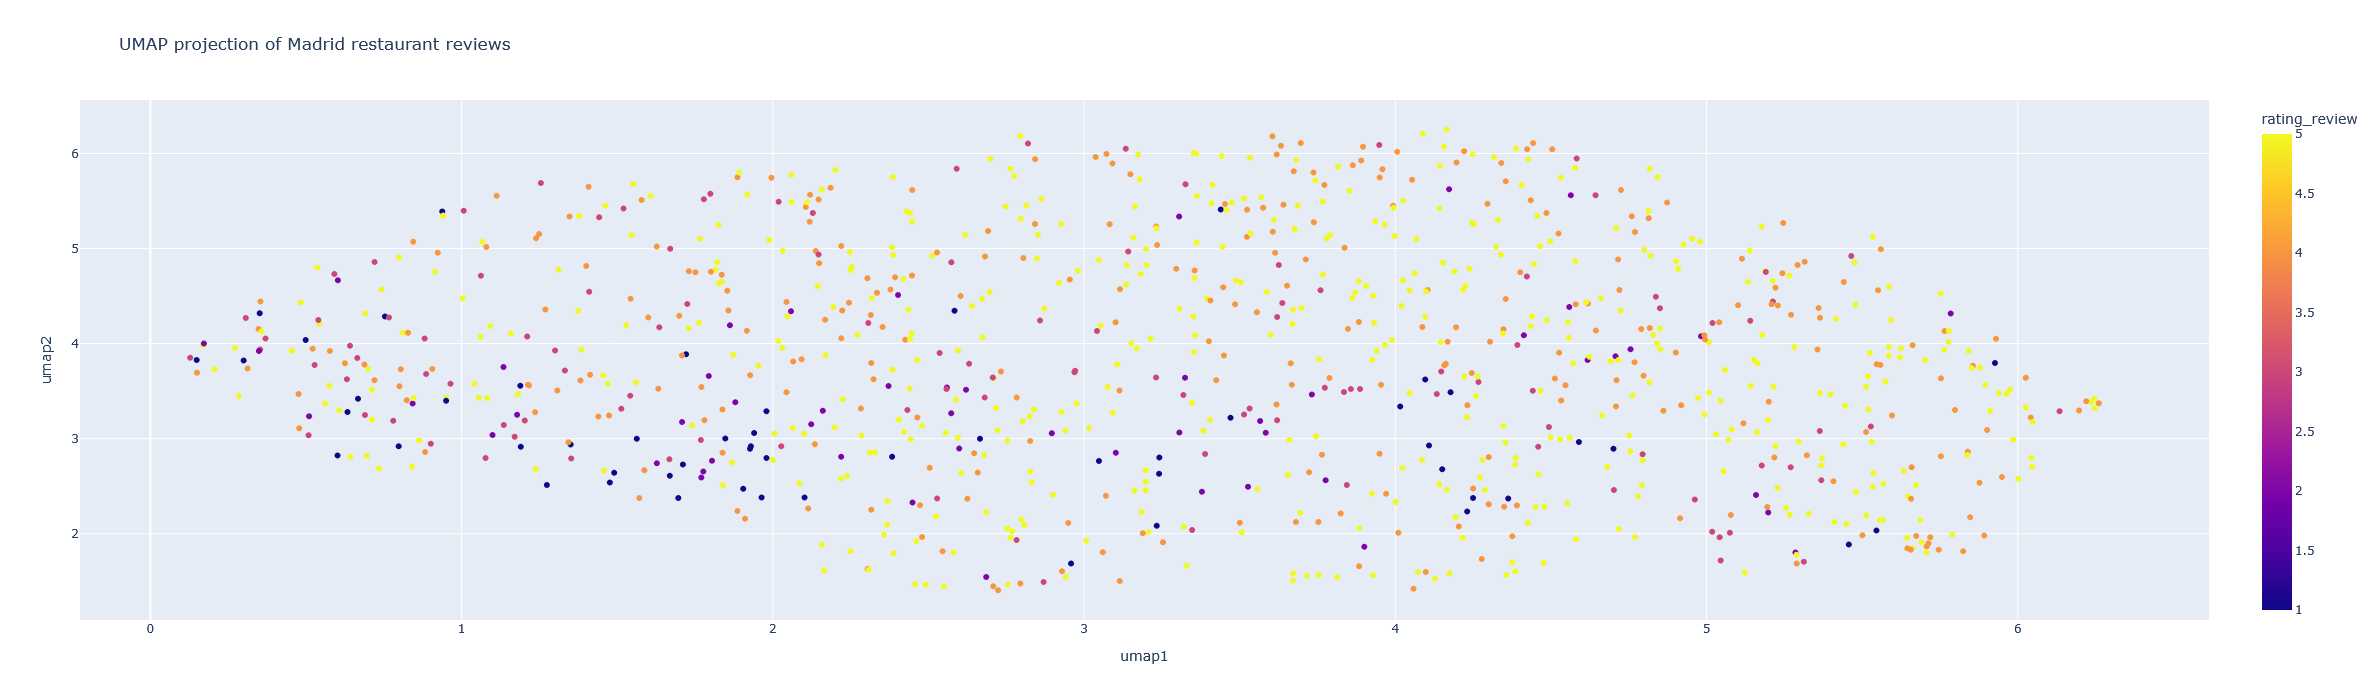

In [104]:
fig = px.scatter(
    data_plot,
    x="umap1",
    y="umap2",
    color="rating_review",
    hover_name="title_review",
    hover_data={
        "rating_review": True,
        "title_review": True,
        "review_start": True,
        "umap1": False,
        "umap2": False,
    },
    title=f"UMAP projection of Madrid restaurant reviews",
)

fig.update_layout(
    autosize=True,
    height=None,
    margin=dict(l=0, r=0, t=50, b=0),
)

# The following is needed for creating the online book. Usually fig.show() is good enough.
html = fig.to_html(
    full_html=False,
    include_plotlyjs="cdn",
    include_mathjax=False,
    config={"responsive": True}
)

display(HTML(f"""
<div style="width: 100%; height: 80vh;">
    {html}
</div>
"""))

### Limitations and More Powerful Alternatives

Word2Vec is a powerful tool because it represents words as dense vectors in a semantic space. Instead of treating each word as an isolated dimension in a large vocabulary, as in simple bag-of-words or TF-IDF representations, Word2Vec learns vectors in which words with similar usage patterns tend to appear close to each other. This makes it possible to compare words by similarity, visualize groups of related words, and use word vectors as building blocks for larger text representations.

For example, word vectors can be combined into simple document vectors by summing or averaging the vectors of all words in a document. These document vectors can then be used for similarity comparisons, clustering, classification, or visualization with dimensionality reduction techniques such as UMAP. This is a useful and intuitive first approach to representing larger pieces of text numerically.

However, this simple approach also shows one of the central limitations of Word2Vec-based document representations. When word vectors are summed or averaged, the result is essentially a **bag of word embeddings**. The document is represented by the words it contains, but not by the order in which they appear. As a result, important linguistic structures such as negation, syntax, and long-range dependencies are usually not captured well. For example, two sentences with similar words but different meanings may receive similar averaged document vectors.

Word2Vec also has limitations at the word level. In a standard Word2Vec model, each word has one fixed vector. This becomes problematic for words with multiple meanings, such as *apple* as a fruit versus *Apple* as a company. Both meanings are represented by the same vector, even though the intended meaning depends strongly on context.

These limitations are partly related to how Word2Vec learns from text. During training, it uses neighboring words within a fixed-size window, but it does not directly model the full structure of a sentence, paragraph, or document. It can learn that certain words tend to occur in similar contexts, but it does not truly process text as an ordered sequence. Even extensions such as n-grams can only capture very local patterns, for example distinguishing *do not like* from *do like*.

This is where sequence-aware and context-aware models become important. Recurrent neural networks process text as an ordered sequence, which allows them to learn patterns that depend on word order. **Transformers** go further by allowing words or subword tokens to interact with many other positions in the text {cite}`vaswani2017attention`. This makes it possible to learn relationships across much longer passages and to build representations that are sensitive to context, word order, and more complex linguistic patterns.

Importantly, modern NLP models do not abandon embeddings. On the contrary, embeddings remain a fundamental building block. Neural language models typically represent words, subwords, sentences, paragraphs, or entire documents internally as vectors. These vectors can then be processed, compared, transformed, and used as input for downstream tasks.

The major difference is that modern models often produce **contextualized embeddings**. Models such as BERT (Bidirectional Encoder Representations from Transformers) {cite}`devlin2018bert` and GPT (Generative Pretrained Transformer) {cite}`radford2019language` do not simply assign one fixed vector to each word. Instead, the representation of a word depends on the surrounding sentence or paragraph. For example, the word *apple* can receive a different representation in a sentence about fruit than in a sentence about technology companies.

Modern NLP models also commonly produce embeddings for larger units of text, such as sentences, paragraphs, or documents. These sentence and document embeddings are widely used for semantic search, duplicate detection, recommendation systems, clustering, retrieval-augmented generation, and many other applications. In this sense, simple document vectors created by summing or averaging Word2Vec vectors are an early and intuitive version of a broader idea: representing text as meaningful numerical vectors.

Working in Python makes it possible to experiment with many of these approaches. Libraries such as *huggingface* {cite}`wolf2019huggingface` provide access to a wide range of transformer models that can generate contextualized word embeddings, sentence embeddings, and document-level representations.

In conclusion, TF-IDF and n-grams provide a useful starting point for representing text numerically. Word2Vec goes further by learning dense semantic word vectors, and simple combinations of these vectors can already be used to represent documents. However, such representations still often behave like a bag of word embeddings and therefore struggle with word order, negation, syntax, and context-dependent meaning. Modern neural NLP methods, especially transformer-based models, build on the same general principle of vector representations, but make these representations contextual, sequence-aware, and much more powerful.


## More on NLP
It should come as no surprise that there is *much* more to learn about NLP than what was presented in this, and the previous chapters.

Very good starting points for going deeper are:
- The book "Speech and Language Processing" by Jurafsky and Martin {cite}`jurafsky2024speech`, see [link to the book](https://web.stanford.edu/~jurafsky/slp3/).
- "Natural language processing with transformers" by Tunstall, von Werra, and Wolf {cite}`tunstall2022natural`
- "The Hundred-Page Language Models Book" by Andriy Burkov {cite}`burkov_hundred_page_2025`
- Another free online course with Python code material: [nlp planet](https://www.nlplanet.org/course-practical-nlp/).